In [1]:
# ============================================================
# CELL 1: IMPORTS
# ============================================================

import os
import re
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2: FILE PATHS
# ============================================================

FINAL_MODEL_DIR = "./final_subscription_model"

MODEL_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "transformer"
)

CONFIG_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "configuration.json"
)

PREPROCESSING_CONFIG_PATH = os.path.join(
    FINAL_MODEL_DIR,
    "preprocessing_config.json"
)

DATA_PATH = "independent_subscription_challenge_300.csv"


print("Model path:", MODEL_PATH)
print("Model exists:", os.path.exists(MODEL_PATH))

print("Configuration exists:", os.path.exists(CONFIG_PATH))

print(
    "Preprocessing configuration exists:",
    os.path.exists(PREPROCESSING_CONFIG_PATH)
)

print("Dataset exists:", os.path.exists(DATA_PATH))

Model path: ./final_subscription_model/transformer
Model exists: True
Configuration exists: True
Preprocessing configuration exists: True
Dataset exists: True


In [3]:
# ============================================================
# CELL 3: LOAD SAVED CONFIGURATION
# ============================================================

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    config = json.load(f)


with open(
    PREPROCESSING_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    preprocessing_config = json.load(f)


TEXT_WEIGHT = float(
    config["text_weight"]
)

RECURRENCE_WEIGHT = float(
    config["recurrence_weight"]
)

THRESHOLD = float(
    config["binary_threshold"]
)

MAX_LENGTH = int(
    config["max_length"]
)


print("=" * 60)

print("SAVED FINAL CONFIGURATION")

print("=" * 60)

print(
    "Text weight:",
    TEXT_WEIGHT
)

print(
    "Recurrence weight:",
    RECURRENCE_WEIGHT
)

print(
    "Binary threshold:",
    THRESHOLD
)

print(
    "Maximum length:",
    MAX_LENGTH
)

print(
    "Vendor masking:",
    preprocessing_config[
        "vendor_masking"
    ]
)

print("=" * 60)

SAVED FINAL CONFIGURATION
Text weight: 1.0
Recurrence weight: 0.0
Binary threshold: 0.1
Maximum length: 256
Vendor masking: True


In [4]:
# ============================================================
# CELL 4: LOAD INDEPENDENT DATASET
# ============================================================

independent_df = pd.read_csv(
    DATA_PATH
)


print("=" * 60)

print("INDEPENDENT DATASET")

print("=" * 60)

print(
    "Shape:",
    independent_df.shape
)

print(
    "\nClass Distribution:"
)

print(
    independent_df[
        "label"
    ]
    .value_counts()
    .sort_index()
)

print(
    "\nUnique customers:",
    independent_df[
        "customer_id"
    ].nunique()
)

print(
    "Unique services:",
    independent_df[
        "service"
    ].nunique()
)

display(
    independent_df.head()
)

INDEPENDENT DATASET
Shape: (300, 9)

Class Distribution:
label
0    150
1    150
Name: count, dtype: int64

Unique customers: 300
Unique services: 40


,id,customer_id,text,label,service,amount,currency,date,frequency
0,CHL00001,ICUST0001,Your Dropbox Plus plan renewed for $20.30. Acc...,1,Dropbox Plus,20.30,USD,2026-09-03,monthly
1,CHL00002,ICUST0002,We received $11.96 for your Notion Plus member...,1,Notion Plus,11.96,USD,2026-08-31,monthly
2,CHL00003,ICUST0003,Zoom Pro: recurring charge of $18.05 was proce...,1,Zoom Pro,18.05,USD,2026-09-08,monthly
3,CHL00004,ICUST0004,Your Grammarly Premium plan renewed for $19.59...,1,Grammarly Premium,19.59,USD,2026-08-31,monthly
4,CHL00005,ICUST0005,Your Duolingo Super plan renewed for $8.74. Ac...,1,Duolingo Super,8.74,USD,2026-09-07,monthly


In [5]:
# ============================================================
# CELL 5: SAME PREPROCESSING AS ORIGINAL MODEL
# ============================================================

def preprocess_email(text):

    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Remove URLs
    text = re.sub(
        r"http\S+|www\.\S+",
        " ",
        text
    )

    # Remove email addresses
    text = re.sub(
        r"\S+@\S+",
        " ",
        text
    )

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


independent_df[
    "clean_text"
] = independent_df[
    "text"
].apply(
    preprocess_email
)


display(
    independent_df[
        [
            "text",
            "clean_text"
        ]
    ].head()
)

,text,clean_text
0,Your Dropbox Plus plan renewed for $20.30. Acc...,Your Dropbox Plus plan renewed for $20.30. Acc...
1,We received $11.96 for your Notion Plus member...,We received $11.96 for your Notion Plus member...
2,Zoom Pro: recurring charge of $18.05 was proce...,Zoom Pro: recurring charge of $18.05 was proce...
3,Your Grammarly Premium plan renewed for $19.59...,Your Grammarly Premium plan renewed for $19.59...
4,Your Duolingo Super plan renewed for $8.74. Ac...,Your Duolingo Super plan renewed for $8.74. Ac...


In [6]:
# ============================================================
# CELL 6: SAME VENDOR MASKING AS TRAINING
# ============================================================

services = preprocessing_config[
    "services"
]

services = sorted(
    [
        str(service)
        for service in services
    ],
    key=len,
    reverse=True
)


def mask_service_name(text):

    result = str(text)

    for service in services:

        if not service.strip():
            continue

        result = re.sub(
            re.escape(service),
            "<vendor>",
            result,
            flags=re.IGNORECASE
        )

    return result


independent_df[
    "model_text"
] = independent_df[
    "clean_text"
].apply(
    mask_service_name
)


display(
    independent_df[
        [
            "service",
            "clean_text",
            "model_text"
        ]
    ].head(10)
)

,service,clean_text,model_text
0,Dropbox Plus,Your Dropbox Plus plan renewed for $20.30. Acc...,Your Dropbox Plus plan renewed for $20.30. Acc...
1,Notion Plus,We received $11.96 for your Notion Plus member...,We received $11.96 for your Notion Plus member...
2,Zoom Pro,Zoom Pro: recurring charge of $18.05 was proce...,Zoom Pro: recurring charge of $18.05 was proce...
3,Grammarly Premium,Your Grammarly Premium plan renewed for $19.59...,Your Grammarly Premium plan renewed for $19.59...
4,Duolingo Super,Your Duolingo Super plan renewed for $8.74. Ac...,Your Duolingo Super plan renewed for $8.74. Ac...
5,iCloud+,Thanks for your iCloud+ payment of $2.78. Prem...,Thanks for your iCloud+ payment of $2.78. Prem...
6,GitHub Copilot,Your GitHub Copilot account will renew automat...,Your GitHub Copilot account will renew automat...
7,LinkedIn Premium,We received $60.34 for your LinkedIn Premium m...,We received $60.34 for your LinkedIn Premium m...
8,Disney+,We received $10.71 for your Disney+ membership...,We received $10.71 for your Disney+ membership...
9,Amazon Prime,Receipt: Amazon Prime plan payment $16.65. Nex...,Receipt: Amazon Prime plan payment $16.65. Nex...


In [7]:
# ============================================================
# CELL 7: LOAD SAVED MODEL
# ============================================================

tokenizer = (
    AutoTokenizer
    .from_pretrained(
        MODEL_PATH
    )
)


model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_PATH
    )
)


# Device selection

if torch.cuda.is_available():

    device = torch.device(
        "cuda"
    )

elif (
    hasattr(
        torch.backends,
        "mps"
    )
    and
    torch.backends.mps.is_available()
):

    device = torch.device(
        "mps"
    )

else:

    device = torch.device(
        "cpu"
    )


model = model.to(
    device
)

model.eval()


print("=" * 60)

print("MODEL LOADED SUCCESSFULLY")

print("=" * 60)

print(
    "Model path:",
    MODEL_PATH
)

print(
    "Device:",
    device
)

print(
    "Number of labels:",
    model.config.num_labels
)

MODEL LOADED SUCCESSFULLY
Model path: ./final_subscription_model/transformer
Device: mps
Number of labels: 2


In [9]:
# ============================================================
# CELL 8: DISTILBERT INFERENCE - FIXED
# ============================================================

texts = (
    independent_df["model_text"]
    .astype(str)
    .tolist()
)

BATCH_SIZE = 32
text_scores = []

for start in range(
    0,
    len(texts),
    BATCH_SIZE
):

    batch_texts = texts[
        start:
        start + BATCH_SIZE
    ]

    encoded = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    # --------------------------------------------------------
    # IMPORTANT FIX FOR DISTILBERT
    # DistilBERT does not use token_type_ids
    # --------------------------------------------------------

    if "token_type_ids" in encoded:
        encoded.pop("token_type_ids")

    # Move tensors to device
    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    # Prediction
    with torch.no_grad():

        outputs = model(
            **encoded
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        # label 1 = subscription
        subscription_probability = (
            probabilities[:, 1]
        )

    text_scores.extend(
        subscription_probability
        .detach()
        .cpu()
        .numpy()
        .tolist()
    )


# Save probability
independent_df[
    "text_score"
] = text_scores


print(
    "Predictions generated:",
    len(text_scores)
)

print(
    "\nText score range:"
)

print(
    "Minimum:",
    independent_df[
        "text_score"
    ].min()
)

print(
    "Maximum:",
    independent_df[
        "text_score"
    ].max()
)

display(
    independent_df[
        [
            "service",
            "label",
            "model_text",
            "text_score"
        ]
    ].head(20)
)

Predictions generated: 300

Text score range:
Minimum: 0.002174761611968279
Maximum: 0.9977003931999207


,service,label,model_text,text_score
0,Dropbox Plus,1,Your Dropbox Plus plan renewed for $20.30. Acc...,0.997509
1,Notion Plus,1,We received $11.96 for your Notion Plus member...,0.996684
2,Zoom Pro,1,Zoom Pro: recurring charge of $18.05 was proce...,0.997149
3,Grammarly Premium,1,Your Grammarly Premium plan renewed for $19.59...,0.997533
4,Duolingo Super,1,Your Duolingo Super plan renewed for $8.74. Ac...,0.997458
5,iCloud+,1,Thanks for your iCloud+ payment of $2.78. Prem...,0.993936
6,GitHub Copilot,1,Your GitHub Copilot account will renew automat...,0.995573
7,LinkedIn Premium,1,We received $60.34 for your LinkedIn Premium m...,0.995892
8,Disney+,1,We received $10.71 for your Disney+ membership...,0.996513
9,Amazon Prime,1,Receipt: Amazon Prime plan payment $16.65. Nex...,0.997268


In [10]:
# ============================================================
# CELL 9: LOCKED FINAL OPERATING POINT
# ============================================================

# Because recurrence weight = 0,
# final hybrid score = text score.

independent_df[
    "final_score"
] = (

    TEXT_WEIGHT
    *
    independent_df[
        "text_score"
    ]

)


independent_df[
    "prediction"
] = (

    independent_df[
        "final_score"
    ]

    >= THRESHOLD

).astype(int)


print("=" * 60)

print("LOCKED FINAL MODEL")

print("=" * 60)

print(
    "Text Weight:",
    TEXT_WEIGHT
)

print(
    "Recurrence Weight:",
    RECURRENCE_WEIGHT
)

print(
    "Threshold:",
    THRESHOLD
)

print("=" * 60)


display(
    independent_df[
        [
            "service",
            "label",
            "text_score",
            "final_score",
            "prediction"
        ]
    ].head(20)
)

LOCKED FINAL MODEL
Text Weight: 1.0
Recurrence Weight: 0.0
Threshold: 0.1


,service,label,text_score,final_score,prediction
0,Dropbox Plus,1,0.997509,0.997509,1
1,Notion Plus,1,0.996684,0.996684,1
2,Zoom Pro,1,0.997149,0.997149,1
3,Grammarly Premium,1,0.997533,0.997533,1
4,Duolingo Super,1,0.997458,0.997458,1
5,iCloud+,1,0.993936,0.993936,1
6,GitHub Copilot,1,0.995573,0.995573,1
7,LinkedIn Premium,1,0.995892,0.995892,1
8,Disney+,1,0.996513,0.996513,1
9,Amazon Prime,1,0.997268,0.997268,1


In [11]:
# ============================================================
# CELL 10: INDEPENDENT EVALUATION
# ============================================================

y_true = (
    independent_df[
        "label"
    ].astype(int)
)

y_pred = (
    independent_df[
        "prediction"
    ].astype(int)
)

y_score = (
    independent_df[
        "final_score"
    ].astype(float)
)


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true,
    y_score
)

pr_auc = average_precision_score(
    y_true,
    y_score
)


print("=" * 70)

print(
    "INDEPENDENT CHALLENGE EVALUATION RESULTS"
)

print("=" * 70)

print(
    f"Records   : {len(independent_df)}"
)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)

print(
    f"ROC-AUC   : {roc_auc:.4f}"
)

print(
    f"PR-AUC    : {pr_auc:.4f}"
)

print("=" * 70)


print(
    "\nCLASSIFICATION REPORT\n"
)

print(
    classification_report(

        y_true,

        y_pred,

        target_names=[
            "Non-Subscription",
            "Subscription"
        ],

        zero_division=0
    )
)

INDEPENDENT CHALLENGE EVALUATION RESULTS
Records   : 300
Accuracy  : 0.9033
Precision : 0.8380
Recall    : 1.0000
F1 Score  : 0.9119
ROC-AUC   : 0.9738
PR-AUC    : 0.9720

CLASSIFICATION REPORT

                  precision    recall  f1-score   support

Non-Subscription       1.00      0.81      0.89       150
    Subscription       0.84      1.00      0.91       150

        accuracy                           0.90       300
       macro avg       0.92      0.90      0.90       300
    weighted avg       0.92      0.90      0.90       300



True Negatives : 121
False Positives: 29
False Negatives: 0
True Positives : 150


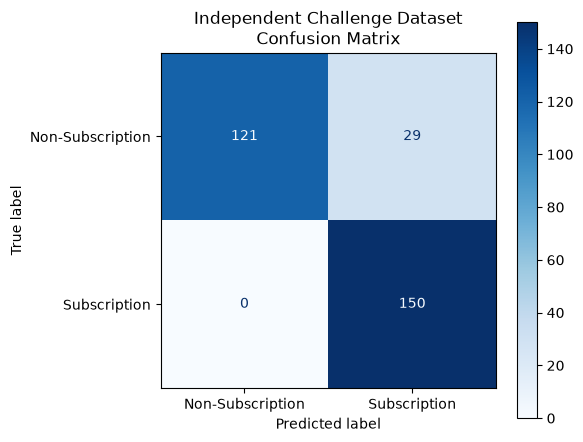

In [12]:
# ============================================================
# CELL 11: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)


tn, fp, fn, tp = cm.ravel()


print(
    "True Negatives :",
    tn
)

print(
    "False Positives:",
    fp
)

print(
    "False Negatives:",
    fn
)

print(
    "True Positives :",
    tp
)


fig, ax = plt.subplots(
    figsize=(6, 5)
)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Non-Subscription",
        "Subscription"
    ]
)


disp.plot(

    cmap="Blues",

    values_format="d",

    ax=ax,

    colorbar=True
)


plt.title(
    "Independent Challenge Dataset\nConfusion Matrix"
)

plt.tight_layout()

plt.show()

In [13]:
# ============================================================
# CELL 12: ERROR ANALYSIS
# ============================================================

errors = independent_df[

    independent_df[
        "label"
    ]

    !=

    independent_df[
        "prediction"
    ]

].copy()


print(
    "Total incorrect predictions:",
    len(errors)
)


display(
    errors[
        [
            "id",
            "service",
            "text",
            "label",
            "text_score",
            "prediction"
        ]
    ]
)

Total incorrect predictions: 29


,id,service,text,label,text_score,prediction
120,CHL00121,Apple Services,Your Apple Store accessory order from Apple Se...,0,0.968121,1
121,CHL00122,Google Play,Your movie rental from Google Play was charged...,0,0.992164,1
122,CHL00123,Adobe Creative Cloud,Your Adobe Stock single asset purchase from Ad...,0,0.720585,1
127,CHL00128,Netflix,Your Netflix gift card purchase from Netflix w...,0,0.931650,1
129,CHL00130,ChatGPT Plus,Your API credit top-up from ChatGPT Plus was c...,0,0.984008,1
130,CHL00131,Apple Services,Your device repair payment from Apple Services...,0,0.988267,1
134,CHL00135,Microsoft 365,Your Microsoft Store mouse order from Microsof...,0,0.961303,1
135,CHL00136,YouTube Premium,Payment $80.08 received for YouTube movie rent...,0,0.167368,1
136,CHL00137,Spotify Premium,Payment $46.00 received for Spotify gift card ...,0,0.135524,1
137,CHL00138,Netflix,Your Netflix gift card purchase from Netflix w...,0,0.802798,1


In [14]:
# ============================================================
# CELL 13: FP / FN ANALYSIS
# ============================================================

false_positives = independent_df[

    (
        independent_df[
            "label"
        ] == 0
    )

    &

    (
        independent_df[
            "prediction"
        ] == 1
    )

].copy()


false_negatives = independent_df[

    (
        independent_df[
            "label"
        ] == 1
    )

    &

    (
        independent_df[
            "prediction"
        ] == 0
    )

].copy()


print(
    "False Positives:",
    len(false_positives)
)

print(
    "False Negatives:",
    len(false_negatives)
)


print(
    "\nFALSE POSITIVES"
)

display(
    false_positives[
        [
            "service",
            "text",
            "label",
            "text_score",
            "prediction"
        ]
    ]
)


print(
    "\nFALSE NEGATIVES"
)

display(
    false_negatives[
        [
            "service",
            "text",
            "label",
            "text_score",
            "prediction"
        ]
    ]
)

False Positives: 29
False Negatives: 0

FALSE POSITIVES


,service,text,label,text_score,prediction
120,Apple Services,Your Apple Store accessory order from Apple Se...,0,0.968121,1
121,Google Play,Your movie rental from Google Play was charged...,0,0.992164,1
122,Adobe Creative Cloud,Your Adobe Stock single asset purchase from Ad...,0,0.720585,1
127,Netflix,Your Netflix gift card purchase from Netflix w...,0,0.931650,1
129,ChatGPT Plus,Your API credit top-up from ChatGPT Plus was c...,0,0.984008,1
130,Apple Services,Your device repair payment from Apple Services...,0,0.988267,1
134,Microsoft 365,Your Microsoft Store mouse order from Microsof...,0,0.961303,1
135,YouTube Premium,Payment $80.08 received for YouTube movie rent...,0,0.167368,1
136,Spotify Premium,Payment $46.00 received for Spotify gift card ...,0,0.135524,1
137,Netflix,Your Netflix gift card purchase from Netflix w...,0,0.802798,1



FALSE NEGATIVES


,service,text,label,text_score,prediction


In [15]:
# ============================================================
# CELL 14: FINAL RESULT TABLE
# ============================================================

independent_results = pd.DataFrame({

    "Evaluation Dataset": [
        "Independent Challenge Dataset"
    ],

    "Records": [
        len(independent_df)
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1 Score": [
        f1
    ],

    "ROC-AUC": [
        roc_auc
    ],

    "PR-AUC": [
        pr_auc
    ],

    "Threshold": [
        THRESHOLD
    ]

})


display(
    independent_results.round(4)
)

,Evaluation Dataset,Records,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Threshold
0,Independent Challenge Dataset,300,0.9033,0.838,1.0,0.9119,0.9738,0.972,0.1
